In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, ks_2samp
from factor_model import FactorModel, reconstruct_returns, load_model
from factor_diffusion_train import *
from factor_diffusion_sample import *

In [26]:
train_model = load_model(f"{PREFIX}")
test_model = load_model(f"{PREFIX}/test")
print(PREFIX)

model/regression


In [27]:
R_df = pd.read_parquet(train_model.data_source)
R_testdf = pd.read_parquet(test_model.data_source)
common_stocks = np.intersect1d(R_df['csecid'].unique(), R_testdf['csecid'].unique())
col_indices = np.searchsorted(R_df['csecid'].values, common_stocks)
sorted_stocks = np.sort(R_df['csecid'].unique())
col_indices = np.searchsorted(np.sort(R_df['csecid'].unique()), common_stocks)
R_testdf = R_testdf[R_testdf['csecid'].isin(common_stocks)]
R_df = R_df[R_df['csecid'].isin(common_stocks)]
R_train_stock_count = R_df['csecid'].nunique()
R_test_stock_count = R_testdf['csecid'].nunique()
print(f"Common stocks: {len(common_stocks)}  Train stocks: {R_train_stock_count}  Test stocks: {R_test_stock_count}")

Common stocks: 2153  Train stocks: 2153  Test stocks: 2153


In [28]:
R_train = R_df.pivot_table(index="date", columns="csecid", values="returns").values
rng = np.random.default_rng(42)
row_idx = rng.choice(R_train.shape[0], size=NUM_GENERATE, replace=False)
R_rs = R_train[row_idx, :]
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values
print(f"Train returns: {R_train.shape}  NaN fraction: {np.isnan(R_train).mean():.2%}")
print(f"Test returns:  {R_test.shape}   NaN fraction: {np.isnan(R_test).mean():.2%}")
print(f"Resample returns: {R_rs.shape}  NaN fraction: {np.isnan(R_rs).mean():.2%}")

Train returns: (2739, 2153)  NaN fraction: 32.60%
Test returns:  (1175, 2153)   NaN fraction: 14.04%
Resample returns: (2048, 2153)  NaN fraction: 32.62%


In [29]:

sampled_factors = np.load(f"{PREFIX}/samples/factor_{MODE}_{NUM_GENERATE}.npy")
fs_full = np.column_stack([
    np.ones((len(sampled_factors), 1), dtype=np.float32),
    sampled_factors.astype(np.float32),
])
R_gen = reconstruct_returns(train_model, fs_full)[:, col_indices]
print(f"Generated: {R_gen.shape}")

Generated: (2048, 2153)


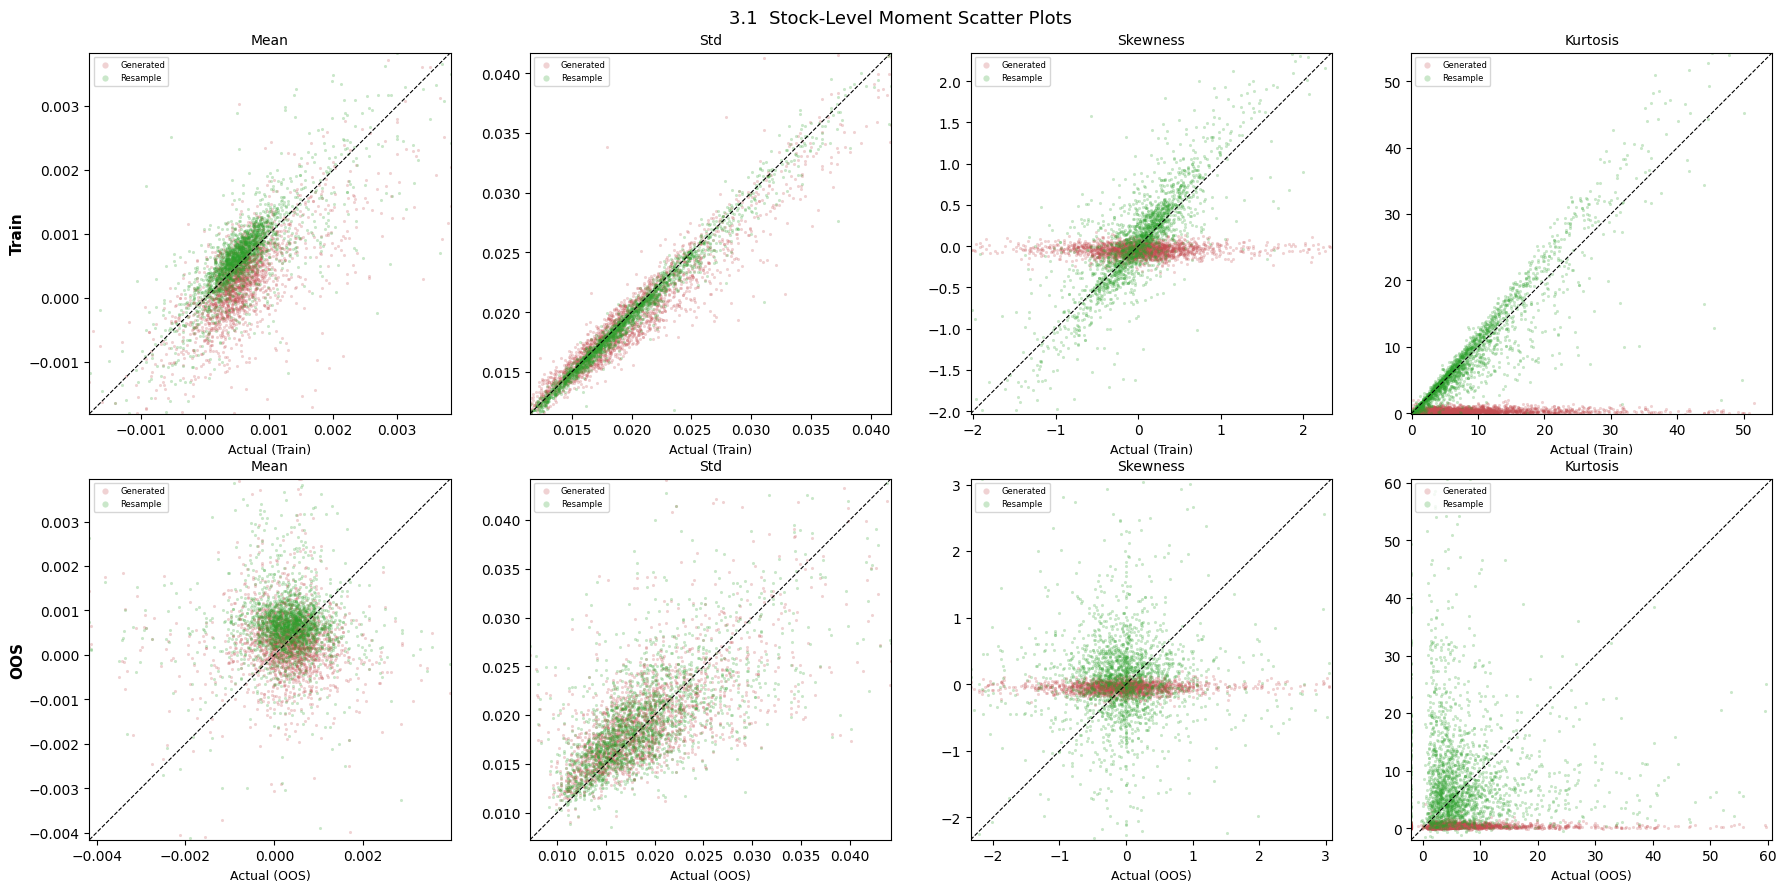

In [30]:
## 3.1 Stock-Level Moment Scatter Plots

MOMENTS = {
    "Mean":     lambda X: np.nanmean(X, axis=0),
    "Std":      lambda X: np.nanstd(X, axis=0),
    "Skewness": lambda X: skew(X, axis=0, nan_policy="omit"),
    "Kurtosis": lambda X: kurtosis(X, axis=0, nan_policy="omit"),
}

m_actual_tr  = {k: fn(R_train)    for k, fn in MOMENTS.items()}  #  training
m_actual_oos = {k: fn(R_test) for k, fn in MOMENTS.items()}  #  OOS
m_gen        = {k: fn(R_gen)        for k, fn in MOMENTS.items()}  # generated
m_rs         = {k: fn(R_rs)         for k, fn in MOMENTS.items()}  # resample baseline

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (mname, _) in enumerate(MOMENTS.items()):
    for row, (actual_label, m_actual) in enumerate([
            ("Train",  m_actual_tr),
            ("OOS",    m_actual_oos)]):
        ax  = axes[row, col]
        x   = m_actual[mname]
        y_g = m_gen[mname]
        y_r = m_rs[mname]

        mask_g = np.isfinite(x) & np.isfinite(y_g)
        mask_r = np.isfinite(x) & np.isfinite(y_r)

        all_vals = np.concatenate([x[mask_g], y_g[mask_g],
                                   x[mask_r], y_r[mask_r]])
        lo = np.percentile(all_vals, 1)
        hi = np.percentile(all_vals, 99)

        ax.scatter(x[mask_g], y_g[mask_g], s=5, alpha=0.25, linewidths=0,
                   color="#c44e52", label="Generated")
        ax.scatter(x[mask_r], y_r[mask_r], s=5, alpha=0.25, linewidths=0,
                   color="#2ca02c", label="Resample")
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel(f"Actual ({actual_label})", fontsize=9)
        ax.set_title(mname, fontsize=10)
        ax.set_aspect("equal")
        ax.legend(fontsize=6, markerscale=2, loc="upper left")

for row, label in enumerate(["Train", "OOS"]):
    axes[row, 0].annotate(label, xy=(-0.22, 0.5), xycoords="axes fraction",
                          fontsize=11, rotation=90, va="center", fontweight="bold")

fig.suptitle("3.1  Stock-Level Moment Scatter Plots", fontsize=13)
fig.tight_layout()
plt.show()


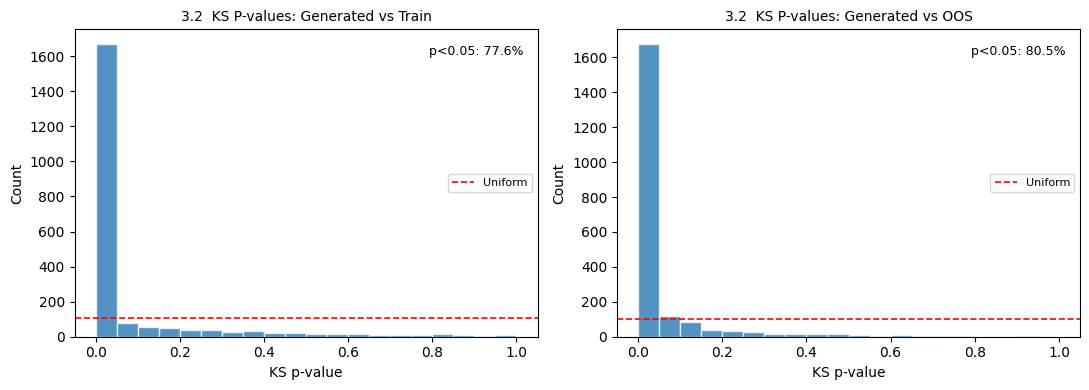

In [31]:
## 3.2 Distribution of KS Test P-values
pvals_train, pvals_oos = [], []
S = R_train.shape[1]

for s in range(S):
    g   = R_gen[:, s];   g   = g[np.isfinite(g)]
    tr  = R_train[:, s]; tr  = tr[np.isfinite(tr)]
    oos = R_test[:, s];  oos = oos[np.isfinite(oos)]
    if len(g) > 5 and len(tr)  > 5: pvals_train.append(ks_2samp(g, tr).pvalue)
    if len(g) > 5 and len(oos) > 5: pvals_oos.append(ks_2samp(g, oos).pvalue)

pvals_train = np.array(pvals_train)
pvals_oos   = np.array(pvals_oos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for ax, pv, label in [(ax1, pvals_train, "Generated vs Train"),
                      (ax2, pvals_oos,   "Generated vs OOS")]:
    n_bins = 20
    ax.hist(pv, bins=n_bins, range=(0, 1), color="#1a6faf", alpha=0.75, edgecolor="white")
    ax.axhline(len(pv) / n_bins, color="red", linestyle="--", lw=1.2, label="Uniform")
    ax.set_xlabel("KS p-value", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"3.2  KS P-values: {label}", fontsize=10)
    ax.legend(fontsize=8)
    frac = (pv < 0.05).mean()
    ax.text(0.97, 0.95, f"p<0.05: {frac:.1%}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

fig.tight_layout()
plt.show()


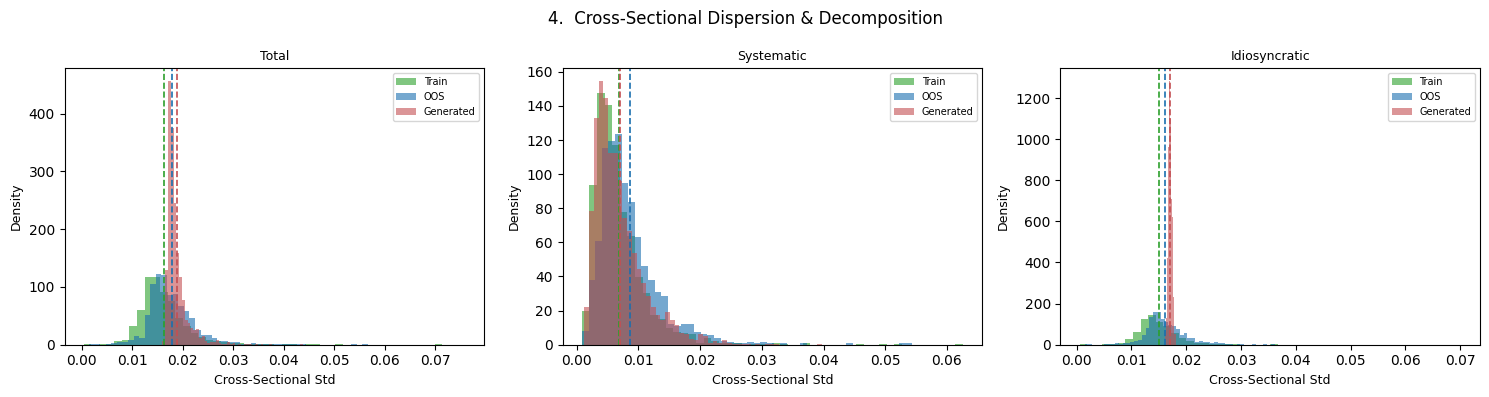

In [33]:
beta_c   = train_model.beta[:, col_indices]
res_std_c = train_model.res_std[col_indices]

_test_full = pd.read_parquet(test_model.data_source)
col_indices_test = np.searchsorted(np.sort(_test_full['csecid'].unique()), common_stocks)

R_train_cs = R_df.pivot_table(index="date", columns="csecid", values="returns").values
sys_train  = train_model.F.values.astype(np.float32) @ beta_c          # (2738, 2153)
idio_train = train_model.residuals[:, col_indices].astype(np.float32)   # (2738, 2153)

R_oos_cs = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values
sys_oos  = test_model.F.values.astype(np.float32) @ beta_c              # (1174, 2153)
idio_oos = test_model.residuals[:, col_indices_test].astype(np.float32) # (1174, 2153)


sys_gen  = fs_full @ beta_c                                                          # (N, 2153)
idio_gen = (np.random.default_rng(42).standard_normal(sys_gen.shape).astype(np.float32)
            * res_std_c)                                                              # (N, 2153)
R_gen_cs = sys_gen + idio_gen                                                        # (N, 2153)

# ── Plot ──────────────────────────────────────────────────────────────────────
panels = [
    ("Total",         R_gen_cs, R_oos_cs,  R_train_cs),
    ("Systematic",    sys_gen,  sys_oos,   sys_train),
    ("Idiosyncratic", idio_gen, idio_oos,  idio_train),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (comp, gmat, omat, tmat) in zip(axes, panels):
    gv = np.nanstd(gmat, axis=1)
    ov = np.nanstd(omat, axis=1)
    tv = np.nanstd(tmat, axis=1)
    ax.hist(tv, bins=50, density=True, alpha=0.60, color="#2ca02c", label="Train")
    ax.hist(ov, bins=50, density=True, alpha=0.60, color="#1a6faf", label="OOS")
    ax.hist(gv, bins=50, density=True, alpha=0.60, color="#c44e52", label="Generated")
    for val, col in [(tv.mean(), "#2ca02c"), (ov.mean(), "#1a6faf"), (gv.mean(), "#c44e52")]:
        ax.axvline(val, color=col, linestyle="--", lw=1.2)
    r_gen = gv.mean() / (ov.mean() + 1e-12)
    r_tr  = tv.mean() / (ov.mean() + 1e-12)
    ax.set_xlabel("Cross-Sectional Std", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(comp, fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle("4.  Cross-Sectional Dispersion & Decomposition", fontsize=12)
fig.tight_layout()
plt.show()